<a href="https://colab.research.google.com/github/JulTob/Data/blob/main/Analysis_Guide.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 0. Uso de R en Colab y combinación con Python  
Para quienes prefieran utilizar R o una combinación de R y Python, Colab permite ejecutar código R mediante la extensión `rpy2`. A continuación se muestra cómo instalarla y usarla.  

1. **Instalar `rpy2`**: en una celda de código de Python, instala `rpy2` (si no está disponible) con `pip`.  
2. **Cargar la extensión de R**: una vez instalada, activa la extensión con `%load_ext rpy2.ipython`.  
3. **Ejecutar código R**: utiliza la magia de celda `%%R` al inicio de una celda para ejecutar código R. Puedes crear vectores, data frames y usar funciones de R de forma nativa.  

En las celdas siguientes se muestra cómo realizar operaciones básicas en R (aritmética, vectores, matrices, factores, data frames) y cómo importar y manipular un conjunto de datos con `dplyr`.

In [1]:
# Instalar y cargar rpy2
!pip install -q rpy2
%load_ext rpy2.ipython

we can check it works now:

In [9]:
%%R
R.version.string

[1] "R version 4.5.1 (2025-06-13)"


### Useful Libraries

In [10]:
%%R
library(ggplot2)
library(readr)
library(dplyr)

### Basic R

In [2]:
%%R
# Operaciones básicas en R
a <- 3
b <- 5
c(a + b, a * b, b / a)

# Crear un vector y filtrar
v <- c(4, 7, 9, 2)
v[v > 5]

# Crear una matriz y transponerla
m <- matrix(1:6, nrow=2, byrow=TRUE)
t(m)

# Crear un factor (categorías)
colores <- factor(c("rojo", "verde", "rojo", "azul"))
levels(colores)

# Crear un data frame y filtrar filas
datos <- data.frame(ciudad=c("Madrid","Valencia","Sevilla","Bilbao"),
                    temp_max=c(40,38,41,33),
                    temp_min=c(22,21,25,18))
subset(datos, temp_max >= 39)

   ciudad temp_max temp_min
1  Madrid       40       22
3 Sevilla       41       25


In [3]:
%%R
# Instalar paquetes necesarios
if (!require('dplyr')) install.packages('dplyr', repos='http://cran.us.r-project.org')
if (!require('readr')) install.packages('readr', repos='http://cran.us.r-project.org')

# Leer datos desde un CSV
df <- read.csv('/content/sample_data/california_housing_train.csv')

# Seleccionar columnas y filtrar
library(dplyr)
df_subset <- select(df, longitude, latitude, housing_median_age)
df_filtered <- filter(df, housing_median_age > 30)

# Crear nueva columna densidad
df <- mutate(df, densidad = population / total_rooms)

# Resumen estadístico
summary(select(df, median_income, median_house_value))

 median_income     median_house_value
 Min.   : 0.4999   Min.   : 14999    
 1st Qu.: 2.5664   1st Qu.:119400    
 Median : 3.5446   Median :180400    
 Mean   : 3.8836   Mean   :207301    
 3rd Qu.: 4.7670   3rd Qu.:265000    
 Max.   :15.0001   Max.   :500001    


Loading required package: dplyr

Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

Loading required package: readr


# Práctica 1: Introducción a Python y Colab para Análisis de Datos  

En esta guía se adapta la primera práctica de la asignatura **Análisis Exploratorio y Comunicación en Ciencia de Datos** a un entorno de Python ejecutado en Google Colab. Aunque la práctica original usa R y RStudio, aquí usaremos Python y sus bibliotecas estándar (como `pandas` y `numpy`) para demostrar conceptos equivalentes. Cada sección incluye explicaciones y ejemplos ilustrativos en código.  

> **Nota**: El objetivo no es traducir literalmente R a Python sino mostrar cómo resolver problemas similares de forma clara, paso a paso y con código modular y comentado. Sugerencias y mejoras son bienvenidas.

## 1. Introducción a Python y Colab  

Python es un lenguaje de programación de propósito general con una sintaxis sencilla y gran ecosistema de bibliotecas. Colab es un entorno en la nube que permite ejecutar código Python en notebooks interactivos.  

- **Ejecutar código**: cada celda de código se ejecuta de forma independiente usando `Ctrl+Enter` o el botón de ejecutar.  
- **Variables**: puedes asignar valores a variables y reutilizarlas en otras celdas.  
- **Documentación integrada**: usa `help(funcion)` o `?funcion` para ver la ayuda de una función.  

En las siguientes secciones utilizaremos Colab para ilustrar conceptos de análisis de datos.

## 2. Comandos básicos en Python  

En R se utiliza el intérprete como calculadora y para asignar valores a objetos. En Python ocurre lo mismo. A continuación se presentan algunos ejemplos de operaciones aritméticas y asignación de variables.

In [4]:
# Operaciones aritméticas básicas
suma = 2 + 3
resta = 5 - 7
producto = 4 * 6
division = 8 / 2
potencia = 2 ** 3  # 2 elevado a 3

print("Suma:", suma)
print("Resta:", resta)
print("Producto:", producto)
print("División:", division)
print("Potencia:", potencia)

# Asignación y reutilización de variables
x = 10
y = 3
z = x * y + 5
print("Valor de z:", z)

# Uso de funciones integradas
abs_valor = abs(-12)       # valor absoluto
raiz = pow(16, 0.5)        # raíz cuadrada
redondeo = round(3.14159, 2)  # redondear a 2 decimales

print("Valor absoluto:", abs_valor)
print("Raíz cuadrada:", raiz)
print("Número redondeado:", redondeo)

Suma: 5
Resta: -2
Producto: 24
División: 4.0
Potencia: 8
Valor de z: 35
Valor absoluto: 12
Raíz cuadrada: 4.0
Número redondeado: 3.14


## 3. Creación y manipulación de objetos  

En R se utilizan distintos tipos de objetos (vectores, matrices, factores, listas, data frames). Python ofrece estructuras equivalentes:  

- **Tipos básicos y operadores lógicos**: números, cadenas, booleanos. Los operadores relacionales (`>`, `<`, `>=`, `<=`, `==`, `!=`) comparan valores y devuelven booleanos.  
- **Funciones integradas**: Python dispone de numerosas funciones predefinidas (`len`, `sum`, `min`, `max`, etc.) y puedes importar módulos como `math` para funciones adicionales.  
- **Listas (vectores)**: las listas permiten almacenar secuencias de elementos. También podemos usar `numpy` para vectores/matrices numéricas y aprovechar operaciones vectorizadas.  
- **Matrices y arrays**: `numpy` permite crear matrices multidimensionales y realizar operaciones algebraicas de forma eficiente.  
- **Categorías (factores)**: en `pandas` existe el tipo `Categorical` para representar variables categóricas.  
- **Listas heterogéneas**: en Python una lista puede contener elementos de distintos tipos. Para estructuras etiquetadas se emplean diccionarios.  
- **DataFrames**: `pandas.DataFrame` es la estructura fundamental para representar tablas de datos, similar a los data frames de R.  

A continuación se muestran ejemplos.

In [5]:
import numpy as np
import pandas as pd

# Operadores lógicos
a = 5
b = 3
print("a > b:", a > b)
print("a <= b:", a <= b)
print("a == b:", a == b)

# Listas y filtrado
lista = [1, 3, 6, 8, 2, 7]
mayores_5 = [x for x in lista if x > 5]
print("Elementos mayores que 5:", mayores_5)

# Numpy arrays y matrices
vector = np.array([1, 2, 3, 4])
matriz = np.array([[1, 2], [3, 4], [5, 6]])
print("Vector * 2:", vector * 2)
print("Matriz transpuesta:\n", matriz.T)

# Categorías con pandas
colores = pd.Series(['rojo', 'azul', 'rojo', 'verde'], dtype="category")
print("Categorías:", colores.cat.categories)

# DataFrame y subsetting
data = pd.DataFrame({
    'ciudad': ['Madrid', 'Valencia', 'Sevilla', 'Bilbao'],
    'temp_max': [40, 38, 41, 33],
    'temp_min': [22, 21, 25, 18]
})
# Filtrar filas donde temp_max >= 39
calor = data[data['temp_max'] >= 39]
print(calor)

a > b: True
a <= b: False
a == b: False
Elementos mayores que 5: [6, 8, 7]
Vector * 2: [2 4 6 8]
Matriz transpuesta:
 [[1 3 5]
 [2 4 6]]
Categorías: Index(['azul', 'rojo', 'verde'], dtype='object')
    ciudad  temp_max  temp_min
0   Madrid        40        22
2  Sevilla        41        25


## 4. Instalación de librerías  

En R se instalan paquetes mediante `install.packages("nombre")`. En Python se utiliza `pip`. En Colab las bibliotecas populares como `numpy` y `pandas` ya están instaladas, pero podemos instalar otras mediante una celda de código anteponiendo un `!`:

In [6]:
# Instalar una biblioteca (ejemplo comentado)
# !pip install seaborn  # descomenta para instalar
pass

## 5. Lectura de datos desde ficheros externos  

Python permite leer datos en distintos formatos usando `pandas`:  

- `pd.read_csv` para archivos CSV con separadores comunes.  
- `pd.read_table` para archivos delimitados por tabulaciones u otros separadores.  
- `pd.read_excel` para archivos de Excel.  

A continuación se muestra cómo importar un archivo CSV de ejemplo incluido en Colab.

In [7]:
import pandas as pd

# Leer un CSV de ejemplo (california housing)
df = pd.read_csv('/content/sample_data/california_housing_train.csv')
print(df.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -114.31     34.19                15.0       5612.0          1283.0   
1    -114.47     34.40                19.0       7650.0          1901.0   
2    -114.56     33.69                17.0        720.0           174.0   
3    -114.57     33.64                14.0       1501.0           337.0   
4    -114.57     33.57                20.0       1454.0           326.0   

   population  households  median_income  median_house_value  
0      1015.0       472.0         1.4936             66900.0  
1      1129.0       463.0         1.8200             80100.0  
2       333.0       117.0         1.6509             85700.0  
3       515.0       226.0         3.1917             73400.0  
4       624.0       262.0         1.9250             65500.0  


## 6. Manipulación de conjuntos de datos  

Con `pandas` se pueden realizar operaciones de selección, filtrado, ordenación y resumen de datos de manera intuitiva. Algunos ejemplos:  

- Seleccionar columnas: `df['columna']` o `df[['col1','col2']]`.  
- Filtrar filas con condiciones lógicas: `df[df['columna'] > valor]`.  
- Crear nuevas columnas a partir de otras: `df['nueva'] = df['col1'] + df['col2']`.  
- Resumir datos: `df.describe()`, `df.mean()`, etc.

In [8]:
# Seleccionar columnas
subset = df[['longitude', 'latitude', 'housing_median_age']]
# Filtrar por edad de viviendas mayor a 30
filtered = df[df['housing_median_age'] > 30]
# Crear nueva columna densidad
df['densidad'] = df['population'] / df['total_rooms']
# Mostrar resumen estadístico
print(df[['median_income','median_house_value']].describe())

       median_income  median_house_value
count   17000.000000        17000.000000
mean        3.883578       207300.912353
std         1.908157       115983.764387
min         0.499900        14999.000000
25%         2.566375       119400.000000
50%         3.544600       180400.000000
75%         4.767000       265000.000000
max        15.000100       500001.000000


### 1. Importar los datos
Importamos la información del Directorio Central de Empresas (DIRCE) para la provincia de Alicante.

Tipo empresa | Codigo | Frecuencia absoluta
----| --- | ----
Sociedad Anónima| SA| 2173
Sociedad Responsabilidad Limitada| SRL| 49088
Sociedad Colectiva| SCol| 15
Sociedad Comandataria| SCom| 3
Comunidad de Bienes| CB| 4783
Sociedad Cooperativa| SCoop| 752
Asociaciones y otros tipos| Asoc| 3081
Organismo Autónomos y otros| OrgAut| 219
Personas Físicas| PerF| 72092

### Tipo de variable

Variable Categórica Cualitativa Nominal: El tipo de empresa

### Nivel de Medición

Nivel de Medición Nominal

### Tabla de Frecuencias

In [11]:
%%R
tipo_empresa <- c("SA", "SRL", "SCol", "SCom", "CB", "SCoop", "Asoc", "OrgAut", "PerF")
ni <- c(2173, 49088, 15, 3, 4783, 752, 3081, 219, 72092)

datos <- data.frame(tipo_empresa, ni)
datos

  tipo_empresa    ni
1           SA  2173
2          SRL 49088
3         SCol    15
4         SCom     3
5           CB  4783
6        SCoop   752
7         Asoc  3081
8       OrgAut   219
9         PerF 72092


Añadimos la frecuencia con cuatro decimales

In [12]:
%%R
datos$fi <- round(datos$ni / sum(datos$ni), 4)
datos

  tipo_empresa    ni     fi
1           SA  2173 0.0164
2          SRL 49088 0.3713
3         SCol    15 0.0001
4         SCom     3 0.0000
5           CB  4783 0.0362
6        SCoop   752 0.0057
7         Asoc  3081 0.0233
8       OrgAut   219 0.0017
9         PerF 72092 0.5453


O de manera porcentual:

In [13]:
%%R
datos$fi_porc <- round(datos$fi * 100, 2)
datos

  tipo_empresa    ni     fi fi_porc
1           SA  2173 0.0164    1.64
2          SRL 49088 0.3713   37.13
3         SCol    15 0.0001    0.01
4         SCom     3 0.0000    0.00
5           CB  4783 0.0362    3.62
6        SCoop   752 0.0057    0.57
7         Asoc  3081 0.0233    2.33
8       OrgAut   219 0.0017    0.17
9         PerF 72092 0.5453   54.53


### Gráfico de Barras (Histograma)

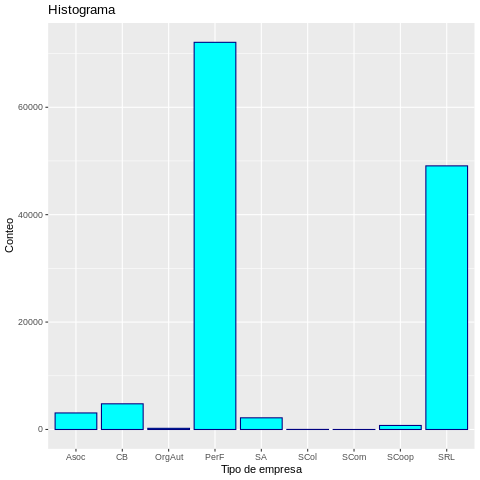

In [14]:
%%R
ggplot(datos, aes(x = tipo_empresa, y = ni)) +
  geom_bar(stat = "identity", color = "navy", fill = "cyan") +
  xlab("Tipo de empresa") +
  ylab("Conteo") +
  ggtitle("Histograma")

Podemos visualizar los datos de más peso en el porcentaje con un gráfico circular (pie chart)

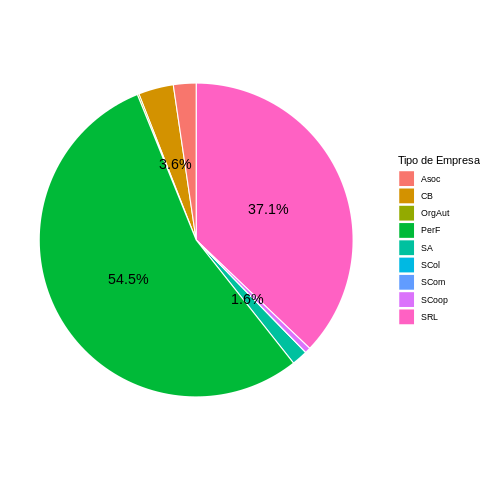

In [15]:
%%R
ggplot(datos, aes("", fi_porc, fill = tipo_empresa)) +
  geom_col(width = 1, color = "white") +
  coord_polar(theta = "y") +
  geom_text(aes(label = scales::percent(fi, accuracy = 0.1)),
            position = position_stack(vjust = 0.5),
            check_overlap = TRUE,
            size = 5) +
  guides(fill = guide_legend(title = "Tipo de Empresa")) +
  theme_void()


Podemos comparar estos métodos de representación y ver que en ambos perdemos visibilidad de 'los pequeños jugadores' del sector. Pueden dar una idea general de los grandes sectores, pero se pierde granularidad en la interpretación.
